In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
excel_file = pd.ExcelFile("Telco_Customer_Churn_Analysis_Cleaned.xlsx")
print(excel_file.sheet_names)

['Cleaned_dataset', 'Pivot_Analysis']


In [46]:
df=pd.read_excel("Telco_Customer_Churn_Analysis_Cleaned.xlsx",sheet_name="Cleaned_dataset")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-3 Years,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3-4 Years,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,1-2 Years,0
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,5+ Years,0
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0-1 Year,0
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,0-1 Year,1


In [47]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-3 Years,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3-4 Years,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,1


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [49]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Tenure_Group        0
Churn_Flag          0
dtype: int64

In [50]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [51]:
churn_rate = df['Churn_Flag'].mean()*100
print("Overall Churn Rate:", round(churn_rate,2), "%")

Overall Churn Rate: 26.58 %


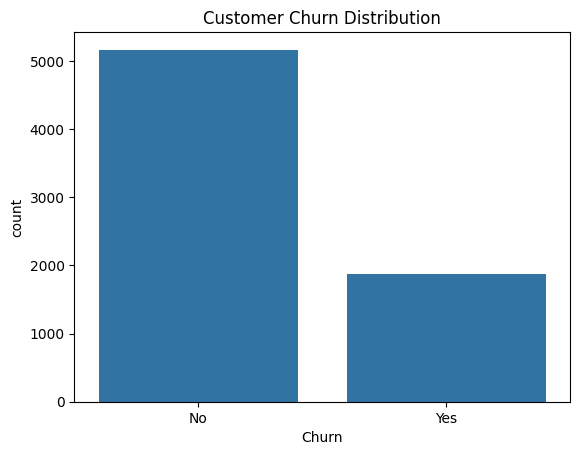

In [52]:
sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.savefig("Customer_Churn_Distribution.png")
plt.show()

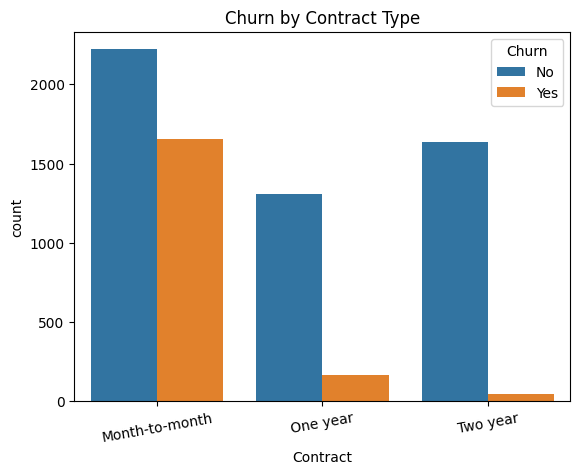

In [53]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.xticks(rotation=10)
plt.savefig("churn_by_contract.png")
plt.show()

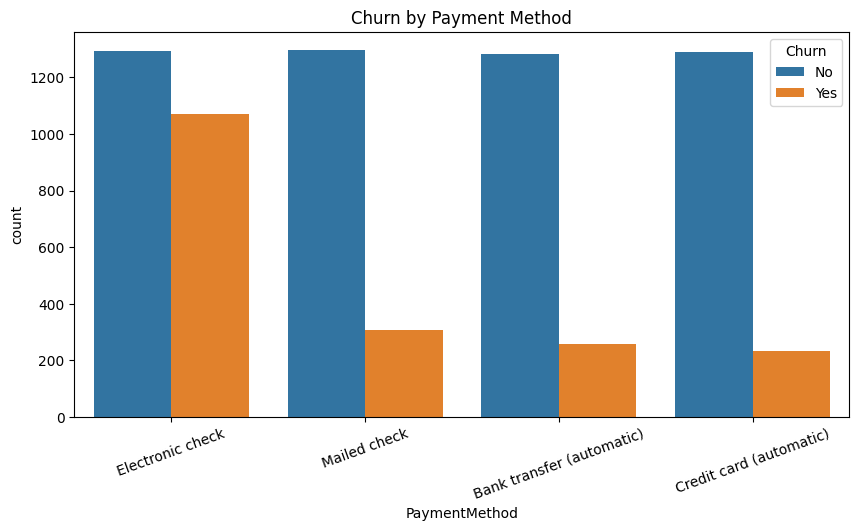

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x='PaymentMethod',
              hue='Churn')

plt.xticks(rotation=20)
plt.title("Churn by Payment Method")
plt.savefig("churn_by_Payment_method.png")
plt.show()

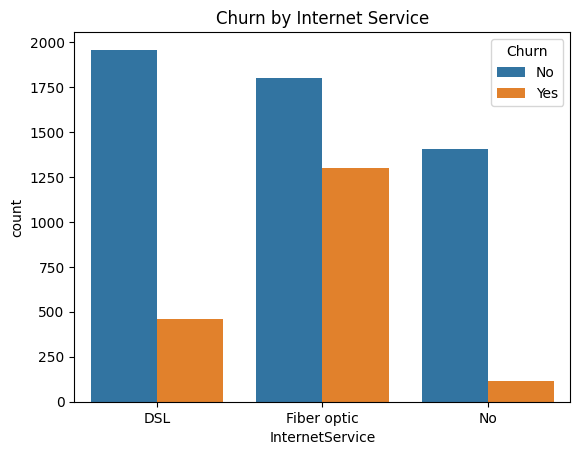

In [55]:
sns.countplot(data=df,
              x='InternetService',
              hue='Churn')

plt.title("Churn by Internet Service")
plt.savefig("churn_by_internet_service.png")
plt.show()

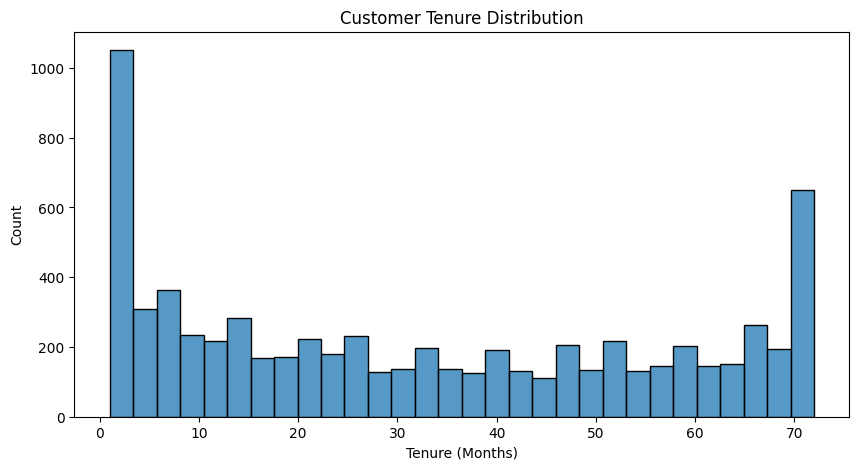

In [56]:
plt.figure(figsize=(10,5))

sns.histplot(df['tenure'], bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.savefig("churn_by_customer_tenure_Distribution.png")
plt.show()

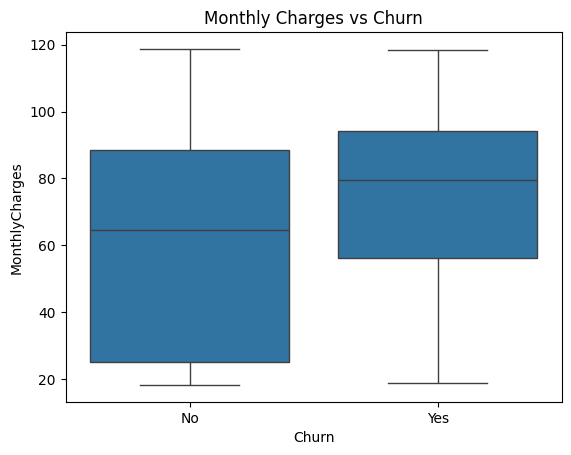

In [57]:
sns.boxplot(x='Churn',
            y='MonthlyCharges',
            data=df)

plt.title("Monthly Charges vs Churn")
plt.savefig("monthly_charges_vs_churn.png")
plt.show()

In [58]:
retention = df.groupby('Tenure_Group')['Churn_Flag'].mean()*100
print(retention)

Tenure_Group
0-1 Year     47.678161
1-2 Years    28.710938
2-3 Years    21.634615
3-4 Years    19.028871
4-5 Years    14.423077
5+ Years      6.609808
Name: Churn_Flag, dtype: float64


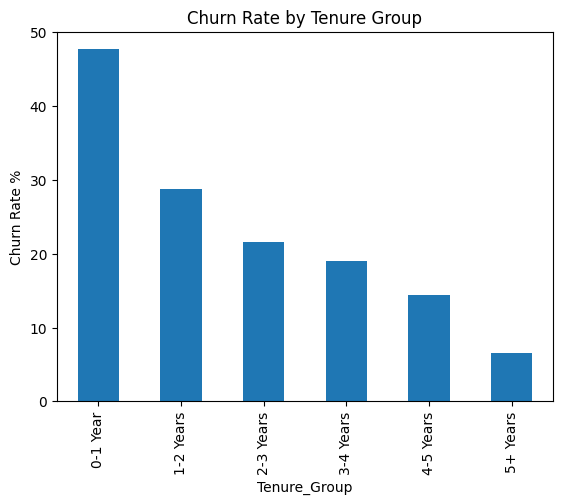

In [59]:
retention.plot(kind='bar')

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate %")
plt.savefig("churn_rate_by_tenure_group.png")
plt.show()

In [60]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

In [61]:
top_customers = df.sort_values(by='CLV', ascending=False)
top_customers[['customerID','CLV']].head()

,customerID,CLV
4578,7569-NMZYQ,8550.0
6109,9924-JPRMC,8510.4
4602,2889-FPWRM,8481.6
3200,3810-DVDQQ,8467.2
6757,9739-JLPQJ,8460.0


In [62]:
df.to_excel("Telco_Customer_Churn_Analysis_Updated.xlsx", index=False)